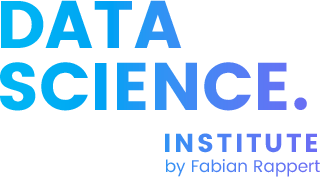

# Monte-Carlo-Simulationen

**Hinweis:** Dieses Notebook soll lediglich ein Anwendungsbeispiel demonstrieren. Ihr braucht weder die mathematischen Details verstehen, noch müsst ihr diesen Code selbst reproduzieren können. Jedoch möchten wir euch zeigen, wie man wichtige Problemstellungen in Python-Code mit nur wenigen Zeilen 'übersetzen' kann. 

# Inhaltsverzeichnis 

- **Monte-Carlo-Simulationen**
    - **Idee**
    - **Umsetzung in Python**


Eine **Monte-Carlo-Simulation** ist eine Methode aus der Wahrscheinlichkeitstheorie. Das Ziel ist es, analytisch schwierige Probleme über eine wiederholte Simulation *numerisch* zu lösen. Hierbei erhält man zwar nicht die *analytische* Lösung des Problems, aber bei einer genügend großen Anzahl an Simulationen, kann aufgrund des **Gesetz der großen Zahlen** davon ausgegangen werden, dass die numerische Lösung *nah genug* an der analytischen ist. Es gibt viele Anwendungsgebiete in den Naturwissenschaften und der Mathematik für Monte-Carlo-Simulationen:

- Berechnung von Integralen
- Abbildung komplexer Prozesse ( z.b. Klimamodelle) 
- Untersuchung einer Zufallsvariable
- usw.

In diesem Notebook wollen wir exemplarisch die Kreiszahl $\pi=3.1415...$ durch eine **Monte-Carlo-Simulation** bestimmen. Was wir nämlich mit unserem bisherigen Wissen schon ohne Probleme machen können, ist die zufällige Erzeugung von Zufallszahlen.

## Idee 

Die Idee zur Simulation von $\pi$ ist das zufällige Erzeugen von $N$ Punkten in einem Quadrat der Seitenlänge $2$. Haben wir diese Punkte erzeugt, können wir testen ob die Punkte im Einheitskreis liegen, also ob gilt (nach Pythagoras)
\begin{align}
x^2 + y^2 \leq 1.
\end{align}

Über das Verhältnis der Punkte ausserhalb des Einheitskreises und der innerhalb können wir $\pi$ berechnen. Es gilt (mit Radius $r=1$):

\begin{align}
\frac{Kreisfläche}{Quadratfläche} = \frac{\pi \cdot r^2}{2\cdot 2} = \frac{\pi}{4} 
\end{align}

Diese Gleichung können wir zur gesuchten Größe $\pi$ umformen:

\begin{align}
\pi = \frac{4 \cdot Kreisfläche}{Quadratfläche}
\end{align}

Für den Wert der Kreisfläche setzen wir nun die Anzahl der zufällig erzeugten Punkte *innerhalb* des Kreises ein. Diese Anzahl müssen wir über obige Formel berechnen.<br> 
Für den Wert der Quadratfläche setzen wir die Anzahl der Punkte ein, die sich im Quadrat befinden. Also $N$, wir haben ja alle Punkte im Quadrat erzeugt.

## Umsetzung in Python

Als erstes müssen wir die Punkte im Quadrat erzeugen. Hierfür benutzen wir die Methode 

[`uniform(low,high,size)`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html)

aus dem Modul `numpy.random`. Dies liefert uns Zufallszahlen aus einem Intervall. Über die Parameter `low` und `high` können wir die Ober- und Untergrenze der erzeugten Zahlen bestimmen. Über den Parameter `size` die Dimension. Wir wollen $N$ Punkte in 2 Dimensionen haben. Im folgenden werden $100$ zufällige Punkte im Quadrat erzeugt:

In [ ]:
import numpy as np

N = 100

points = np.random.uniform(low=-1, high=1, size=(N, 2))

Bevor wir nun $\pi\$ berechnen, wollen wir uns das Ergebnis visuell darstellen. Hierzu plotten wir uns die Punkte und den Einheitskreis. Die Achsen werden noch beschriftet und dem Schaubild wird ein Titel gegeben:

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111)

plt.scatter(points[:, 0], points[:, 1])

plt.xlim((-1, 1))
plt.xticks([-1, 0, 1])
plt.xlabel("x")
plt.ylim((-1, 1))
plt.yticks([-1, 0, 1])
plt.ylabel("y")

ax.set_aspect("equal")

circle = plt.Circle((0, 0), 1, color="red", fill=False)

ax.add_patch(circle)

plt.title("Die simulierten Punkte")
plt.show()

Wir sehen eine zufällige Verteilung der Punkte im Quadrat, manche befinden sich *innerhalb* des Kreises, manche *ausserhalb*. Wir wollen nun die Anzahl der Punkte *innerhalb* bestimmen. Für Koordinaten $x,y$ dieser Punkte gilt die Gleichung 
\begin{align}
x^2 + y^2 \leq 1   \quad(\text{Satz von Pythagoras}).
\end{align}

Wir könnten nun durch die Variable `points` mit einer `for-Schleife` iterieren und für jeden Punkt einzeln überprüfen, ob die Gleichung erfüllt ist. Davon ist jedoch *generell* bei numpy-Arrays abzuraten, es geht meistens deutlich eleganter und schneller über eine andere Methode. Wir berechnen uns für alle Punkte den Abstand vom Nullpunkt. 

In [ ]:
abstand = np.sum(points**2, axis=1)
print(abstand)

`points**2` quadriert die einzelnen Koordinaten und `np.sum` addiert sie (vgl. mit obiger Formel).
Wir haben nun ein Array mit den Entfernungen der Punkte vom Ursprung. Nun müssen wir nur noch überprüfen, für welche Punkte aus `points` der Abstand kleiner als 1 ist:

In [ ]:
points_circle = points[abstand <= 1]

`points_circle` ist nun ein Array mit allen Punkten *innerhalb* des Kreises. Wenn wir die **Anzahl** der Punkte haben wollen, können wir wie gewohnt auf `shape` zugreifen:

In [ ]:
number_of_points_in_circle = points_circle.shape[0]
print(f"Punkte innerhalb des Einheitskreises: # {number_of_points_in_circle}")

Daran waren wir interessiert. Jetzt haben wir alle Werte für obige Formel und können einsetzen:

In [ ]:
pi_approximierung = 4 * number_of_points_in_circle / N
print(f"Wir haben PI angenährt zu {pi_approximierung}.")
print(f"Analytischer Wert: {np.pi}")

> <span style="color:gray"> **_AUFGABE:_** </span> Sind wir nahe am analytischen Wert? Ändere den Wert für $N$ und spiele das Notebook nochmals durch. Was ändert sich? 

Wir können nun die obige Funktionalität in eine Funktion bündeln. Diese Funktion erwartet die Zahl $N$ der zu simulierenden Punkte und berechnet dann die Annäherung an $\pi$.

In [ ]:
def simulate_pi(N):
    points = np.random.uniform(-1, 1, size=(N, 2))
    abstand = np.sum(points**2, axis=1)
    points_circle = points[abstand <= 1]
    number_of_points_in_circle = points_circle.shape[0]
    pi_approximierung = 4 * number_of_points_in_circle / N
    return pi_approximierung

Z.B. **Was ist die Annäherung an $\pi$ für $1000$ simulierte Punkte?**

In [ ]:
simulate_pi(1000)

Wenn wir wollen, können wir diese Funktion nun wiederum benutzen, um z.b. die Abhängigkeit von $N$ anzeigen zu lassen:

In [ ]:
pi_approxs = []
N_values = range(2, 1500)

for N in N_values:
    pi_approxs.append(simulate_pi(N))

plt.figure(figsize=(12, 12))
plt.plot(N_values, pi_approxs, "o", markersize=3)

plt.xlim(0, N_values[-1])
plt.xlabel("N")
plt.yticks([3, np.pi, 3.5], labels=[3, r"$\pi$", 3.5])

plt.hlines(np.pi, 0, N_values[-1], color="red", zorder=3, linestyle="solid")

plt.title(r"Approximation von $\pi$ über Monte-Carlo")
plt.show()

> <span style="color:gray"> **_AUFGABE:_** </span> Versuche obigen Code zu verstehen. Was passiert hier? 

Wir sehen deutlich, dass die Annäherung an $\pi$ immer besser wird, je größer $N$ ist. Die Werte für kleine $N$ fluktieren deutlich stärker um den realen Wert von $\pi$. Das gilt *grundsätzlich* für Monte-Carlo-Simulationen. Je mehr Datenpunkte wir haben, desto besser das Ergebnis!